In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [3]:
# creating a synthetic dataset

from sklearn.datasets import make_blobs

x, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)

In [4]:
x

array([[-6.59633932, -7.13901457],
       [-6.13753182, -6.58081701],
       [ 5.19820575,  2.04917508],
       ...,
       [ 3.69047995,  4.60555175],
       [ 4.03036663,  1.78619838],
       [-7.44179522, -7.08933147]], shape=(1000, 2))

In [5]:
y

array([2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0,
       2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
       2, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1,
       1, 2, 0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2,
       0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2,
       1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1,
       1, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1,
       2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2,
       2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 2, 1,
       2, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2,

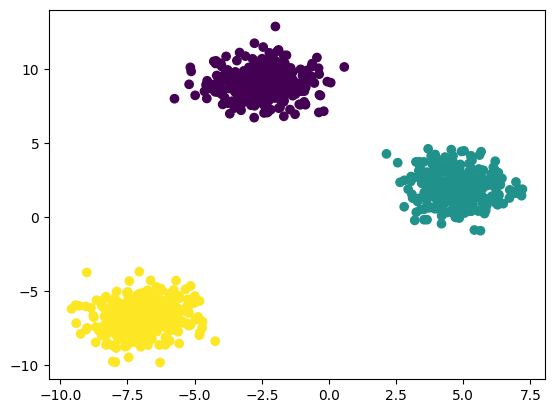

In [6]:
plt.scatter(x[:, 0], x[:, 1], c=y)

In [7]:
# scaling or standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [9]:
x_train_scaled  =   scaler.fit_transform(x_train)
x_test_scaled   =   scaler.transform(x_test)

In [10]:
# model training

from sklearn.cluster import KMeans

# elbow method to select k value

wcss = []

for k in range(1, 11):

    model = KMeans(n_clusters=k, init="k-means++")

    model.fit(x_train_scaled)
    wcss.append(model.inertia_)

In [11]:
wcss

[1339.9999999999998,
 424.77950428412703,
 43.53781728348885,
 37.733150909376704,
 34.71353158147646,
 25.83866551229704,
 26.56892142424426,
 22.41558128864511,
 19.456166432741732,
 19.055914618221156]

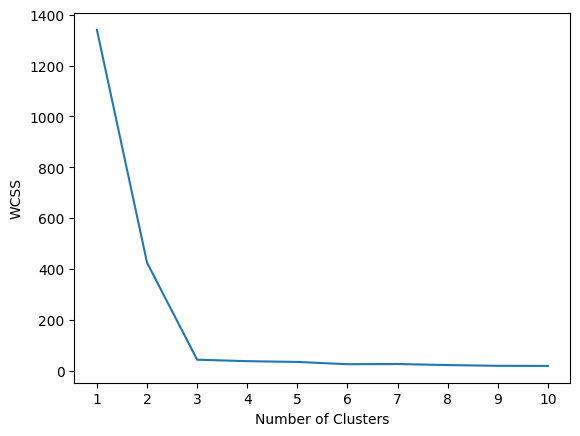

In [12]:
# plotting elbow curve

plt.plot(range(1, 11), wcss)

plt.xticks(range(1, 11))

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [13]:
model = KMeans(n_clusters=3, init="k-means++")

In [14]:
model.fit_predict(x_train_scaled)

array([2, 1, 2, 0, 1, 2, 2, 0, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0,
       1, 0, 0, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 0, 2,
       2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 0, 2, 1, 2, 2, 2, 2, 0,
       1, 1, 1, 2, 2, 1, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 0,
       0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 0, 2, 0, 2, 1, 0, 0, 1, 1, 2,
       0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 2,
       0, 2, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2,
       2, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0,
       2, 2, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 1, 2,
       1, 1, 2, 0, 1, 2, 2, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 1,
       1, 1, 2, 0, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 1,
       2, 0, 2, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 2, 1, 2, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 1, 1, 2, 0,

In [16]:
y_pred = model.predict(x_test_scaled)

In [17]:
y_pred

array([0, 1, 1, 2, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0,
       0, 2, 2, 2, 1, 0, 2, 0, 1, 2, 2, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 2,
       0, 1, 2, 2, 0, 1, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2, 1,
       1, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2,
       2, 2, 0, 1, 2, 1, 0, 0, 2, 1, 2, 1, 0, 2, 2, 0, 0, 0, 1, 1, 2, 2,
       1, 1, 0, 1, 0, 0, 0, 2, 0, 0, 2, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1, 2,
       0, 0, 1, 1, 2, 2, 2, 0, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 2,
       0, 2, 1, 2, 0, 2, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 1, 0,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 0, 1, 2,
       2, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 0, 2,
       1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 2, 1, 1, 2, 0, 2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 1, 2, 1, 1, 2,
       1, 1, 2, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1,

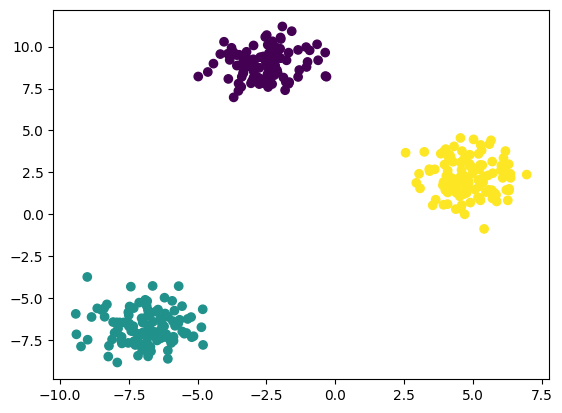

In [18]:
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_pred)

In [19]:
# validation of k value: kneeLocator & Silhoutee scoring

In [20]:
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

In [21]:
kl.elbow

np.int64(3)

In [22]:
# silhouette score

from sklearn.metrics import silhouette_score

silhouette_coeff = []

for k in range(2, 11):

    model = KMeans(n_clusters=k, init="k-means++")

    model.fit(x_train_scaled)

    score = silhouette_score(x_train_scaled, model.labels_)

    silhouette_coeff.append(score)

In [23]:
silhouette_coeff

[0.6857199772837788,
 0.842476016737992,
 0.6774649019945745,
 0.5099108217050237,
 0.354834361896086,
 0.3447771373542454,
 0.337387223815891,
 0.34325175767456917,
 0.32295864879591524]

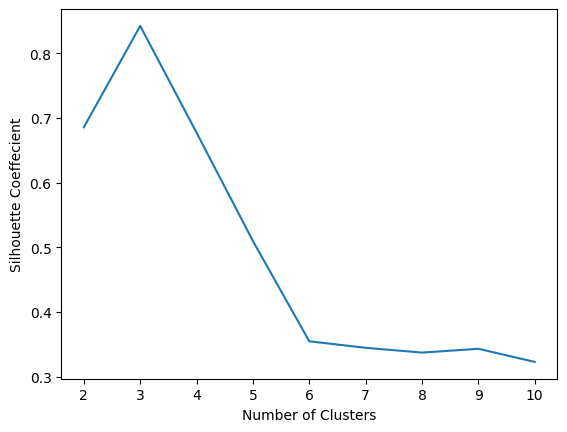

In [24]:
# plotting silhouette score

plt.plot(range(2, 11), silhouette_coeff)

plt.xticks(range(2, 11))

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coeffecient")

plt.show()